In [1]:
%matplotlib inline

# Residence Time Distributions

Residence time theory describes a system with an inlet and an outlet.
The residence time of a particle is the duration it spends within the system.

```{figure} ./resources/system.png
:width: 50%
:align: center
```

The residence time distribution is characterized by the function $E(t)$, which exhibits properties of a probability distribution:
$$E(t) \ge 0 \text{ and } \int_0^\infty E(t) \, dt = 1$$

This function indicates the likelihood of a particle spending a specific duration inside the system.

Residence time distributions are determined by introducing a non-reactive tracer into the system at the inlet:

1. Adjust the input concentration according to a known function (e.g., Dirac $\delta$-function or step function).
2. Measure the output concentration.
3. Convert the output concentration into a residence time distribution curve $E(t)$.

For simple systems like CSTR and plug flow reactors, analytical solutions exist.
These can be compared with CADET simulations.

**In this lesson, you will:**
- Learn about system responses.
- Set up unit operation models manually.
- Analyze solutions and examine the internal dynamics of a column.

## Example 1: Continuous Stirred-Tank Reactor

In an ideal continuous stirred-tank reactor (CSTR), the inlet flow is instantly and completely mixed into the reactor bulk.
The reactor and outlet fluid maintain identical, homogeneous compositions at all times.
The residence time distribution follows an exponential decay:

$$E(t) = \frac{1}{\tau} \cdot e^{-\frac{t}{\tau}}$$

where

$$\tau = \frac{V}{Q}$$

```{note}
In practice, achieving such rapid mixing is impossible, especially in industrial reactors ranging from 1 to thousands of cubic meters. Thus, the RTD of a real reactor will deviate from the ideal exponential decay.
```

To model this system, the following flow sheet is assumed:

```{figure} ./resources/RTD_CSTR.png
:width: 50%
:align: center
```

### CSTR Model

The `CSTR` [model](https://cadet.github.io/master/modelling/unit_operations/cstr.html#cstr-model) in CADET requires the following [parameters](https://cadet.github.io/master/interface/unit_operations/cstr.html#cstr-config):
- Initial volume
- Initial concentration

In subsequent examples, we will associate [adsorption models](https://cadet.github.io/master/modelling/binding/index.html) and [chemical reactions](https://cadet.github.io/master/modelling/reactions.html) with the `CSTR` unit operation.
For this example, we focus solely on convective flow and assume a constant flow rate over time.

Assume the following parameters:

| Parameter           | Value | Unit | Attribute |
| ------------------- | ----- | ---- | --------- |
| Volume              | 1     | L    | `V`       |
| Mean Residence Time | 1     | min  | -         |


**Note:** Since the `CSTR` has a variable volume, the flow rate must also be specified.

In [2]:
from CADETProcess.processModel import ComponentSystem

component_system = ComponentSystem(1)

tau = 60
V = 1e-3
Q = V/tau

# Unit Operations
from CADETProcess.processModel import Inlet, Cstr, Outlet

## Inlet
# We assume constant flow. Concentrations will later be modified using events.
inlet = Inlet(component_system, 'inlet')
inlet.flow_rate = Q

cstr = Cstr(component_system, 'cstr')
cstr.c = [0]
cstr.init_liquid_volume = V
cstr.const_solid_volume = 0
cstr.flow_rate = Q

outlet = Outlet(component_system, 'outlet')

# Flow Sheet
from CADETProcess.processModel import FlowSheet

flow_sheet = FlowSheet(component_system)

flow_sheet.add_unit(inlet)
flow_sheet.add_unit(cstr)
flow_sheet.add_unit(outlet)

flow_sheet.add_connection(inlet, cstr)
flow_sheet.add_connection(cstr, outlet)

### Pulse Experiment in CSTR

This method involves injecting a small volume of concentrated tracer at the CSTR inlet, approximating a Dirac $\delta$-function.
By definition, the integral of this function equals one.
While an infinitely short injection is impractical, it can be much smaller than the mean residence time of the vessel.

```{figure} ./resources/system_dirac.png
:width: 50%
:align: center
```

In [3]:
step_size = 1e-3

from CADETProcess.processModel import Process
process = Process(flow_sheet, 'rtd_cstr')
process.cycle_time = 10 * tau

process.add_event('start peak', 'flow_sheet.inlet.c', 1/step_size, 0)
process.add_event('end peak', 'flow_sheet.inlet.c', 0, step_size)

Event(name=end peak, parameter_path=flow_sheet.inlet.c, state=0, time=0.001, indices=[(slice(None, None, None),)])

### Simulate Process

(<Figure size 354.331x236.22 with 1 Axes>,
 <Axes: xlabel='$Time~/~\\text{min}$', ylabel='$c~/~\\text{mM}$'>)

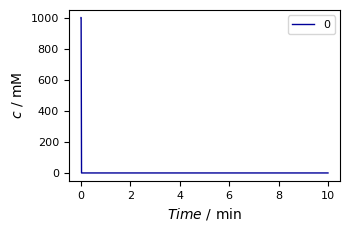

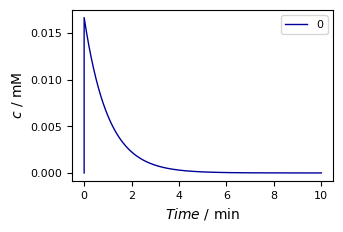

In [4]:
from CADETProcess.simulator import Cadet

simulator = Cadet()

simulation_results = simulator.simulate(process)
simulation_results.solution.cstr.inlet.plot()
simulation_results.solution.cstr.outlet.plot()

## Example 2: Plug Flow Reactor

In an ideal plug flow reactor, fluid elements entering simultaneously move at the same rate and exit together.
Fluid entering at time $t$ exits at time $t + \tau$, where $\tau$ is the residence time.
The distribution function is a Dirac delta function at $\tau$:

```{figure} ./resources/RTD_PFR.png
:width: 50%
:align: center
```

$$E(t) = \delta (t - \tau)$$

The RTD of a real reactor deviates from the ideal due to hydrodynamics, such as axial dispersion within the vessel.

### PFR Model

Although CADET lacks an explicit PFR model, it can be simulated using column models by setting porosity to 1 and axial dispersion to 0.
Here, we use the `LumpedRateModelWithoutPores`.
For model equations, see [here](https://cadet.github.io/master/modelling/unit_operations/lumped_rate_model_without_pores.html), and for parameters, see [here](https://cadet.github.io/master/interface/unit_operations/lumped_rate_model_without_pores.html).

Assume the following parameters:


| Parameter                  | Value | Unit | Attribute            |
| -------------------------- | ----- | ---- | -------------------- |
| Reactor Length             | 1     | L    | `V`                  |
| Reactor Cross Section Area | 0.1   | m²   | `cross_section_area` |
| Mean Residence Time        | 1     | min  | -                    |

In [5]:
from CADETProcess.processModel import ComponentSystem

component_system = ComponentSystem(1)

tau = 60
length = 1
cross_section_area = 0.1
V = cross_section_area * length
Q = V/tau

# Unit Operations
from CADETProcess.processModel import Inlet, TubularReactor, Outlet

## Inlet
# We assume constant flow. Concentrations will later be modified using events.
inlet = Inlet(component_system, 'inlet')
inlet.flow_rate = V/tau

pfr = TubularReactor(component_system, 'pfr')
pfr.length = 1
pfr.cross_section_area = cross_section_area

pfr.axial_dispersion = 0
pfr.solution_recorder.write_solution_bulk = True

outlet = Outlet(component_system, 'outlet')

# Flow Sheet
from CADETProcess.processModel import FlowSheet

flow_sheet = FlowSheet(component_system)

flow_sheet.add_unit(inlet)
flow_sheet.add_unit(pfr)
flow_sheet.add_unit(outlet)

flow_sheet.add_connection(inlet, pfr)
flow_sheet.add_connection(pfr, outlet)

Again add the step function for the inlet profile.

In [6]:
step_size = 1e-3

from CADETProcess.processModel import Process
process = Process(flow_sheet, 'rtd_pfr')
process.cycle_time = 2 * tau

process.add_event('start peak', 'flow_sheet.inlet.c', 1/step_size, 0)
process.add_event('end peak', 'flow_sheet.inlet.c', 0, step_size)

Event(name=end peak, parameter_path=flow_sheet.inlet.c, state=0, time=0.001, indices=[(slice(None, None, None),)])

### Simulate Process

In [7]:
from CADETProcess.simulator import Cadet

simulator = Cadet()

simulation_results = simulator.simulate(process)

Now, we see the new entry "bulk" in the dictionary, since we told the solution recorder to write it:

In [8]:
simulation_results.solution

{'inlet': {'inlet': <CADETProcess.solution.SolutionIO at 0x749039dfb7f0>,
  'outlet': <CADETProcess.solution.SolutionIO at 0x749039bfc0e0>},
 'pfr': {'inlet': <CADETProcess.solution.SolutionIO at 0x749039bfc4d0>,
  'outlet': <CADETProcess.solution.SolutionIO at 0x749039bfc440>,
  'bulk': <CADETProcess.solution.SolutionBulk at 0x749039d6e210>},
 'outlet': {'inlet': <CADETProcess.solution.SolutionIO at 0x749039d4bd10>,
  'outlet': <CADETProcess.solution.SolutionIO at 0x749039d4bad0>}}

The results of inlet and outlet can be plotted as per usual, but in the outlet we notice something is off:

(<Figure size 354.331x236.22 with 1 Axes>,
 <Axes: xlabel='$Time~/~\\text{min}$', ylabel='$c~/~\\text{mM}$'>)

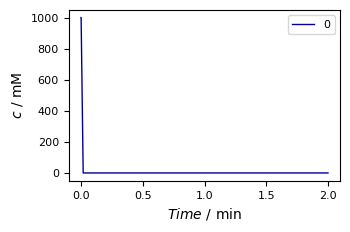

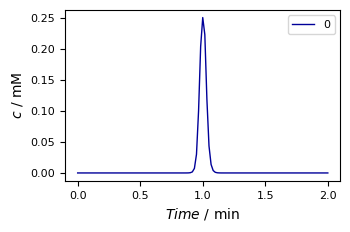

In [9]:
simulation_results.solution.pfr.inlet.plot()
simulation_results.solution.pfr.outlet.plot()

```{warning}
Due to numerical dispersion, solvers like CADET are not well-suited to simulate stiff systems, such as those with zero axial dispersion.
To achieve a more accurate solution, the number of axial cells must be significantly increased, which also substantially increases simulation time.
Since real systems typically exhibit some physical dispersion, this is usually not a problem as it smoothens the profiles.
This example highlights the limitations of CADET and shows that while it may not be highly accurate in this case, the mean residence time value remains as expected.
```

### Discretization

For column models, several options exist for adapting the spatial discretization of the PDE model.
The two most important parameters are the number of grid cells in the column (axial direction) and the particles.
Since the lumped rate model without pores lacks particles, only axial cells `n_col` need to be specified.
The default is $100$, which should suffice for most scenarios.

```{note}
In this workshop, we use CADET with a finite volume scheme for spatial discretization.
However, most unit operation methods now support *Discontinuous Galerkin*, which can significantly increase speed.
Further information on DG can be found [here](https://cadet-process.readthedocs.io/en/v0.11.1/user_guide/process_model/unit_operation.html#discretization).
```

In [10]:
pfr.discretization.ncol

100

### High Discretization

(<Figure size 354.331x236.22 with 1 Axes>,
 <Axes: xlabel='$Time~/~\\text{min}$', ylabel='$c~/~\\text{mM}$'>)

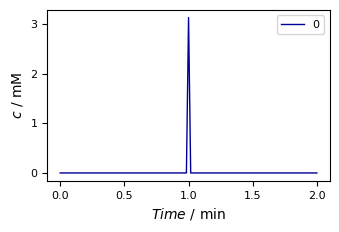

In [11]:
pfr.discretization.ncol = 2000
simulation_results = simulator.simulate(process)
simulation_results.solution.pfr.outlet.plot()